In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

PATH_TO_CSV_FILE = "../data/raw/AmesHousing.csv"

<Axes: xlabel='SalePrice', ylabel='Count'>

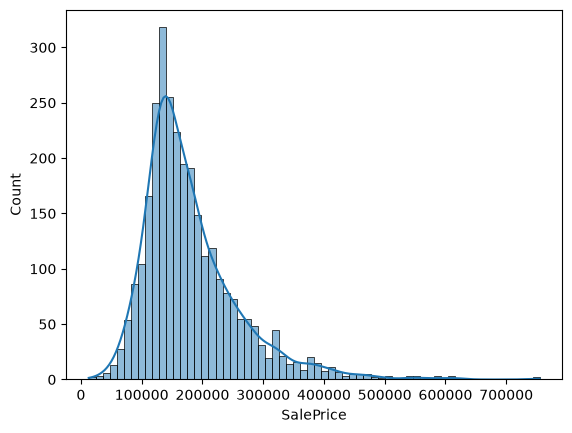

In [2]:
df = pd.read_csv(filepath_or_buffer=PATH_TO_CSV_FILE)
sns.histplot(data=df["SalePrice"], kde=True)

We can see that `SalePrice` is right-skewed — most houses are sold in the **100k–300k range**, but a small number of luxury homes on the right tail drag the mean above the median.

This causes two concrete problems for our models. First, both XGBoost and LightGBM start from the **mean prediction** for all samples — so right away they overestimate every normal home and underestimate the mansions. Second, **MSE squares the residuals**, meaning the already-large errors on expensive houses get amplified even further. The model then focuses its splits on reducing those massive squared errors, effectively ignoring the 95% of typical homes where most of the data actually lives. This is especially dangerous for LightGBM, which grows trees **leaf-wise** — it will keep splitting the same high-error luxury leaves instead of building a balanced tree.

Let's confirm this with the actual skewness score.

In [3]:
print(df["SalePrice"].skew())
print(f"Mean: {df["SalePrice"].mean()}")
print(f"Median: {df["SalePrice"].median()}")

1.7435000757376466
Mean: 180796.0600682594
Median: 160000.0


Skewness of **1.74** confirms what we saw visually. Anything above **1.0** is considered heavily skewed — we're well past that. Time to fix it.

The standard solution is a **log transformation**. Log compresses large values more than small ones, so the mansion prices at the right tail get pulled in significantly while the typical home prices barely move. The distribution should come out much closer to symmetric. Let's check.

<Axes: xlabel='SalePrice', ylabel='Count'>

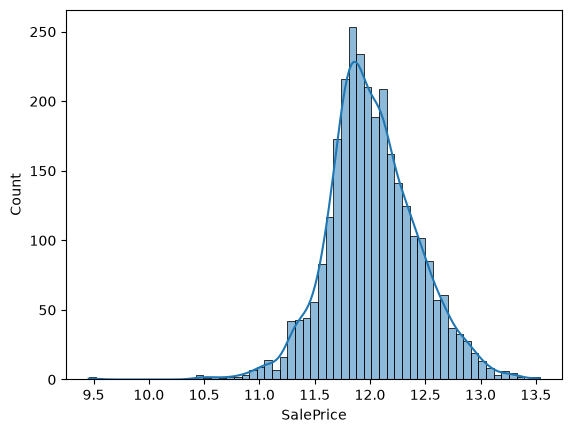

In [4]:
sns.histplot(data=np.log1p(df["SalePrice"]), kde=True)

At first glance the transformed distribution looks slightly left-skewed, but that's not actually a problem. There are just a handful of houses sold at unusually low prices — foreclosures, damaged properties, or non-market sales — that create that small left tail. Because there are so few of them, their contribution to the mean is nearly zero.

The dangerous direction was always the **right tail** — the mansions were the ones inflating the mean and blowing up the residuals. That tail is now gone. Let's verify with the skewness score.

In [5]:
print(np.log1p(df["SalePrice"]).skew())
print(f"Mean: {np.log1p(df["SalePrice"]).mean()}")
print(f"Median: {np.log1p(df["SalePrice"]).median()}")

-0.014772659537224382
Mean: 12.020975245392643
Median: 11.982935344196433


Skewness dropped from **1.74 to -0.015** — essentially zero. The distribution is now symmetric, mean and median are almost identical, and the loss function will treat all price ranges fairly. We'll be predicting **log(SalePrice)** going forward and transforming the predictions back at the end.

Now let's move on to understanding which features actually drive the price. With **80 columns** a full correlation heatmap is unreadable, so we'll first rank all numeric features by their correlation with `SalePrice` and zoom into the top 16.

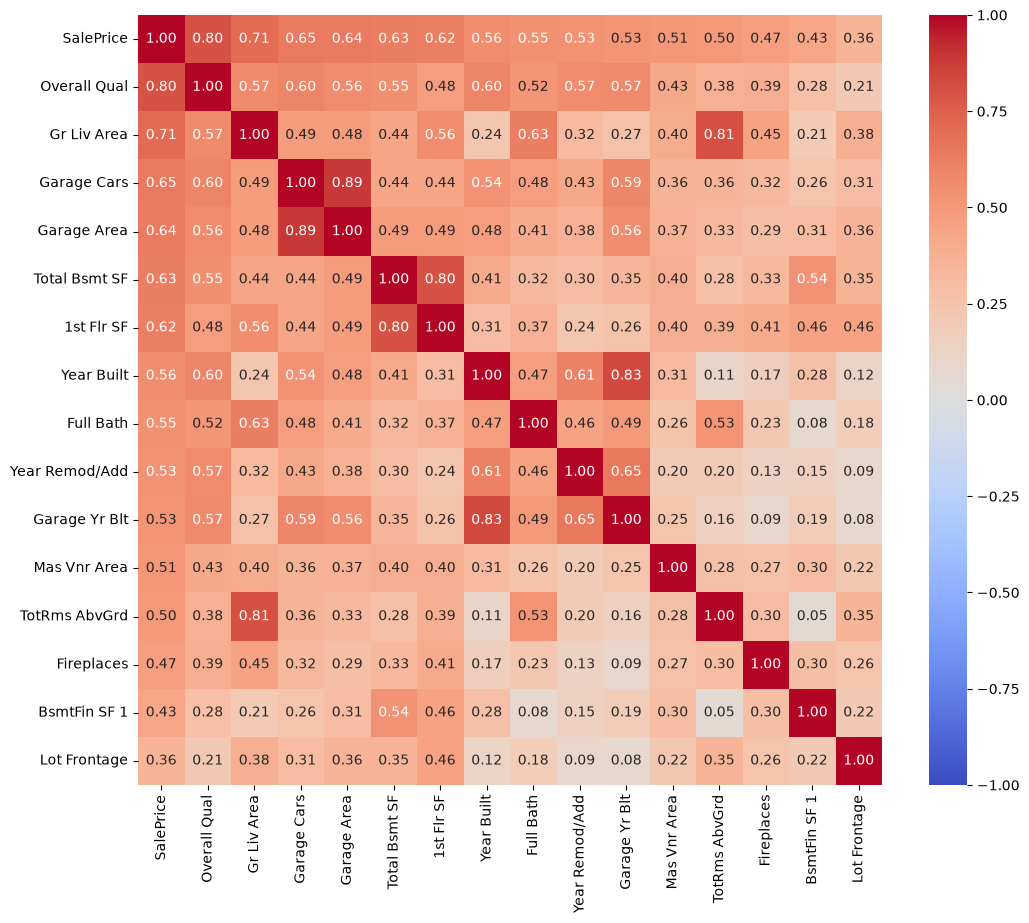

In [6]:
# get the top 15 feature names based on correlation with SalePrice
top_features = (
    df.corrwith(other=df["SalePrice"], numeric_only=True)
    .sort_values(key=abs, ascending=False)
    .head(16)
    .index
)

# compute the 16x16 correlation matrix for those top features
corr_matrix = df[top_features].corr()

# plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

A few things stand out immediately.

**`OverallQual`** has the strongest correlation with `SalePrice` at **0.79** — the overall build quality rating is the single most important numeric signal in the dataset, which makes intuitive sense. After that, **`GrLivArea`** (above-ground living area) and **`GarageCars`** follow, both around **0.60**. Bigger house, more garage space, higher price — no surprises there.

The more interesting finding is the **multicollinearity** between features — several pairs are measuring almost the same thing:

- **`GarageCars` and `GarageArea`** — 0.89 correlation. Both describe garage size, just in different units. Keeping both gives the model redundant information and can confuse it about which one actually matters. We'll drop one in preprocessing.
- **`TotalBsmtSF` and `1stFlrSF`** — 0.80 correlation. In most houses the basement footprint matches the first floor footprint, so these move together almost perfectly.
- **`YearBuilt` and `GarageYrBlt`** — 0.83 correlation. The garage was almost always built the same year as the house, so these are essentially the same feature.
- **`TotRmsAbvGrd` and `GrLivArea`** — 0.81 correlation. More rooms naturally means more living area — they're capturing the same underlying thing.

These pairs are candidates for **dropping one column each** during the preprocessing phase. Feeding both into a linear model would cause instability, and even for tree models it adds noise without adding information.

Features like **`Fireplaces`**, **`WoodDeckSF`**, **`LotFrontage`**, and **`BsmtFinSF1`** sit at the bottom of the top-16 with correlations around **0.28–0.39** — they have some signal but are weak individually. They might still be useful in combination with other features, so we'll keep them for now and let the model figure out their weight.

Correlation numbers tell us the **strength** of the relationship between each feature and `SalePrice`, but not the **shape**. A correlation of 0.60 could mean a clean straight line or a messy curve with outliers pulling the number up — we can't tell from the heatmap alone.

So for the top numeric features we'll plot each one against `log(SalePrice)` directly. We're looking for two things:

- Is the relationship **linear**? Linear regression and even boosting models work best when the feature-target relationship is roughly straight
- Are there **outliers** sitting far from the main trend? A few unusual data points can distort the whole model

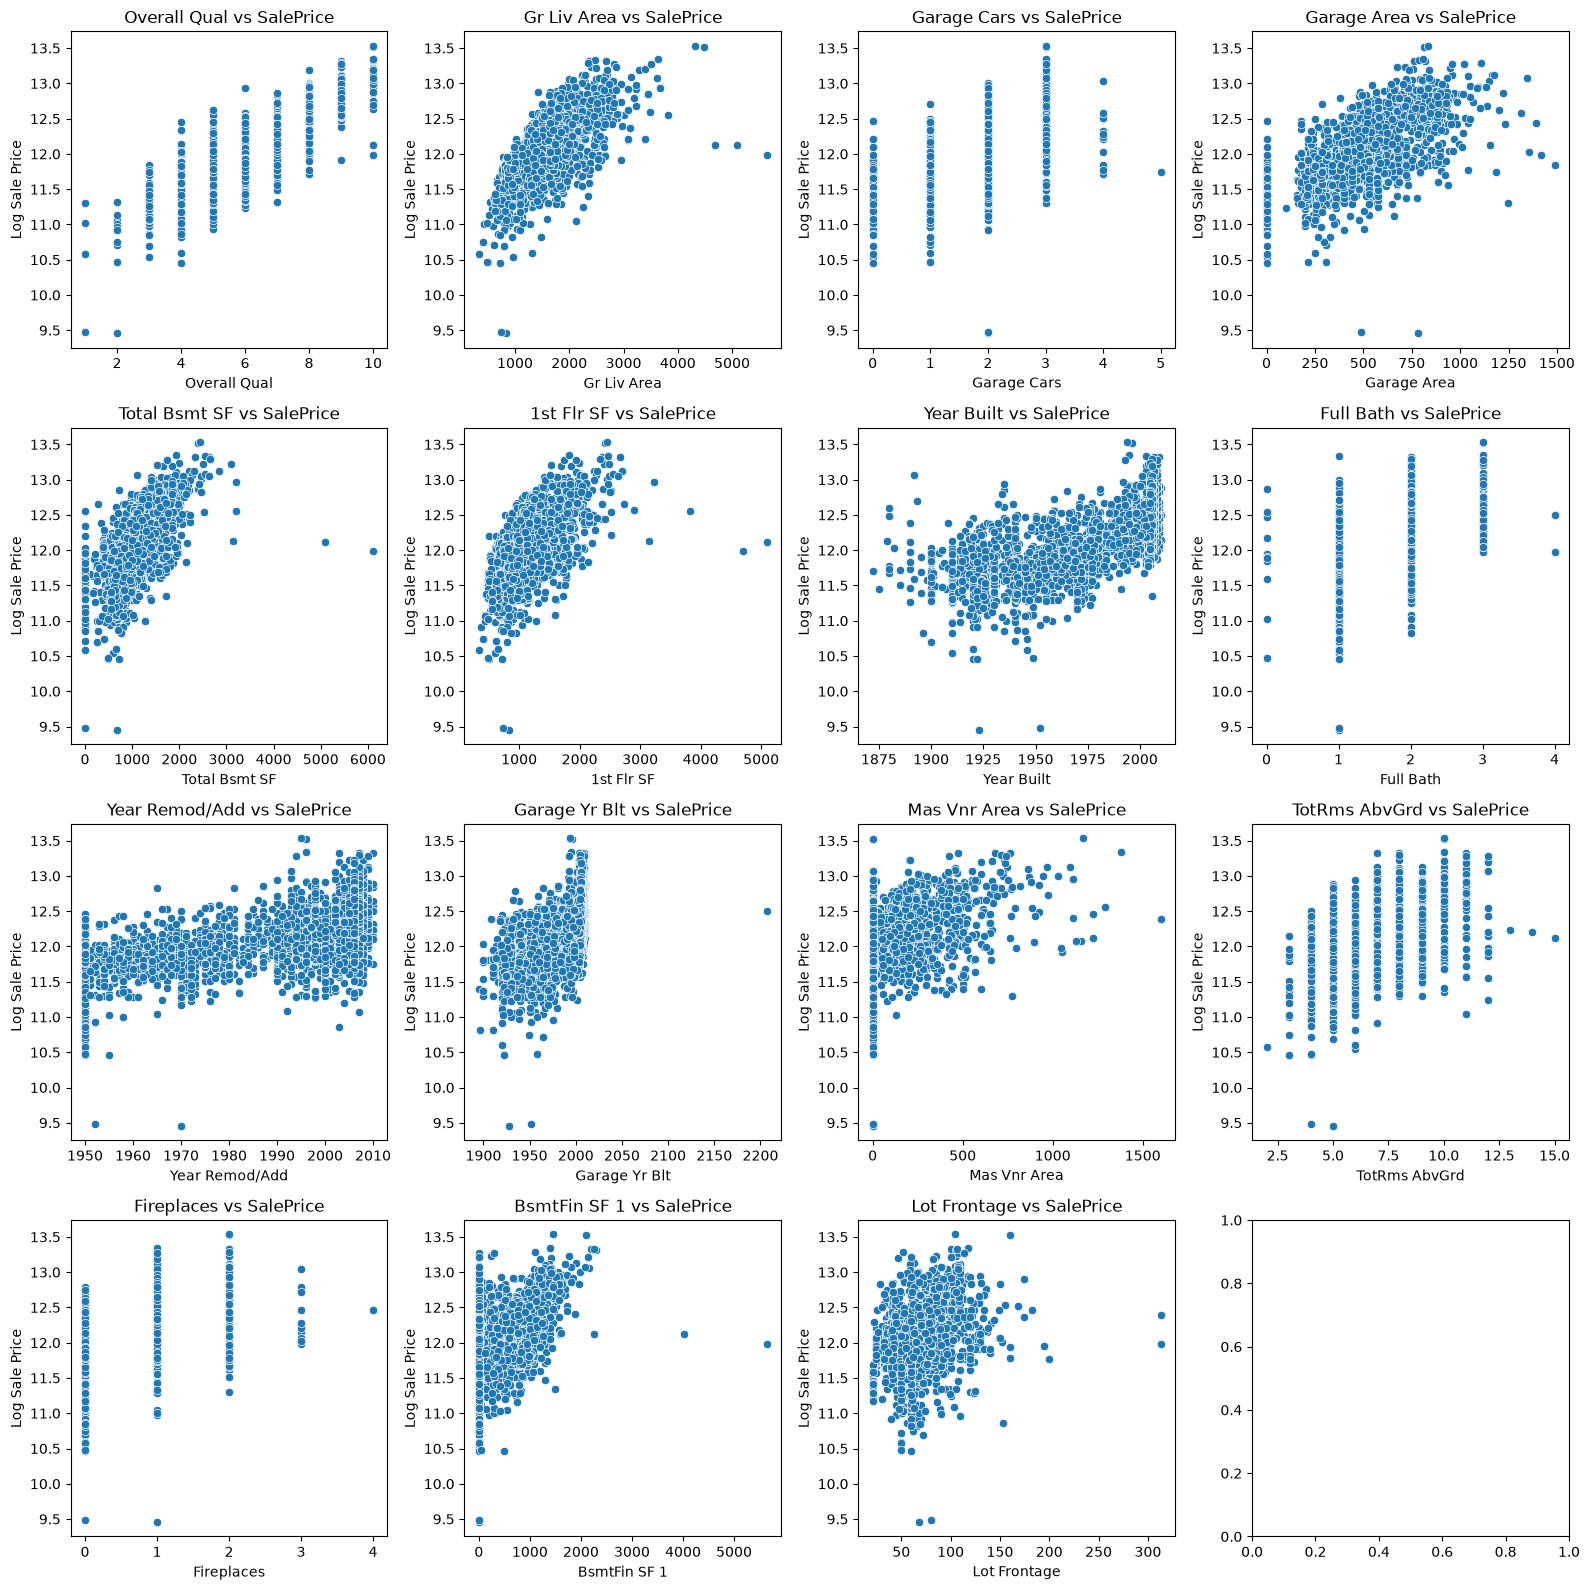

In [ ]:
top_features = (
    df.corrwith(other=df["SalePrice"], numeric_only=True)
    .sort_values(key=abs, ascending=False)
    .head(16)
    .index
)

x_axis = df[top_features].drop(columns="SalePrice")
y_axis = np.log1p(df["SalePrice"])

# create 4 × 4 subplots
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# turn 2D axes array into 1D
axes = axes.flatten()

for i, feature in enumerate(x_axis.columns):

    sns.scatterplot(
        x=x_axis[feature],
        y=y_axis,
        ax=axes[i]
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Log Sale Price")
    axes[i].set_title(f"{feature} vs SalePrice")

plt.tight_layout()
plt.show()

A few observations:

- **`OverallQual`** shows a clean step-up pattern — each quality level consistently sells for more, almost perfectly linear. Strong and reliable feature.
- **`GrLivArea`** is mostly linear but three houses with over **4000 sqft** sold for unusually low prices, sitting far below the trend. These are likely non-market sales — institutional purchases or something similar. They don't represent normal buyer behavior and will hurt the model's ability to learn the true relationship. We'll drop them.
- **`GarageCars`** and **`GarageArea`** both show positive trends but plateau at the high end — very few houses have 3+ car garages so the data gets sparse there.
- **`YearBuilt`** shows that newer houses sell for more, but the relationship fans out — older houses have much more price variance than newer ones, which is expected since renovation history matters a lot for old properties.

The three `GrLivArea` outliers are the only points we'll remove — they're a documented issue with this dataset and dropping them is standard practice.

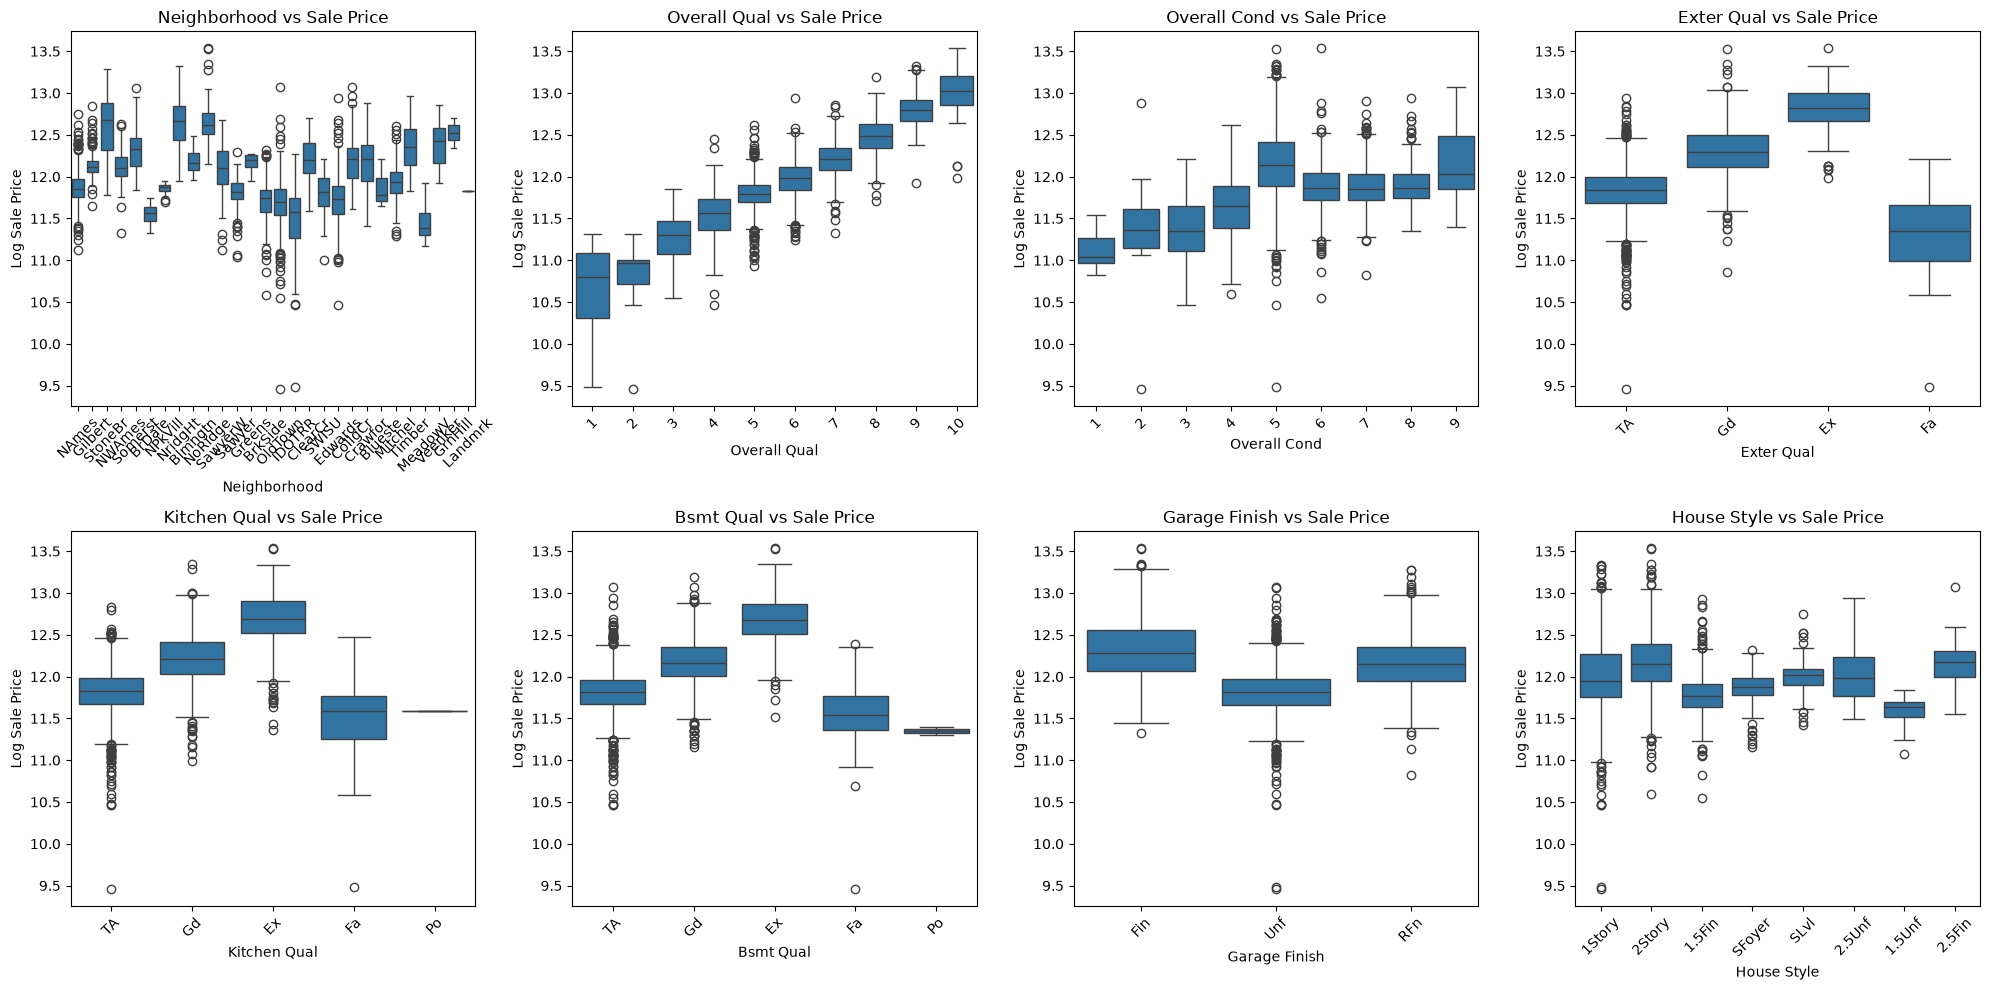

In [21]:
categorical_features = [
    "Neighborhood",
    "Overall Qual",
    "Overall Cond",
    "Exter Qual",
    "Kitchen Qual",
    "Bsmt Qual",
    "Garage Finish",
    "House Style"
]

y_axis = np.log1p(df["SalePrice"])

# Create 2 × 4 subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Flatten axes so we can loop through them
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    sns.boxplot(
        x=df[feature],
        y=y_axis,
        ax=axes[i]
    )

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Log Sale Price")
    axes[i].set_title(f"{feature} vs Sale Price")

    # Rotate labels when there are many categories
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()